In [2]:
import pandas as pd

# Example: Loading a dataset from a URL
# You can replace this URL with the path to your local CSV file or another data source.
dataset_url = '/content/drive/MyDrive/Colab Notebooks/retail_store_inventory.csv'
df = pd.read_csv(dataset_url)

# Display the first few rows of the dataset
print("Dataset loaded successfully. Here's a preview:")
print(df.head())

# Display information about the dataset
print("\nDataset Info:")
df.info()

Dataset loaded successfully. Here's a preview:
         Date Store ID Product ID     Category Region  Inventory Level  \
0  2022-01-01     S001      P0001    Groceries  North              231   
1  2022-01-01     S001      P0002         Toys  South              204   
2  2022-01-01     S001      P0003         Toys   West              102   
3  2022-01-01     S001      P0004         Toys  North              469   
4  2022-01-01     S001      P0005  Electronics   East              166   

   Units Sold  Units Ordered  Demand Forecast  Price  Discount  \
0         127             55           135.47  33.50        20   
1         150             66           144.04  63.01        20   
2          65             51            74.02  27.99        10   
3          61            164            62.18  32.72        10   
4          14            135             9.26  73.64         0   

  Weather Condition  Holiday/Promotion  Competitor Pricing Seasonality  
0             Rainy                  0

### Data Cleaning

In [3]:
# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

print("Data types after converting 'Date' column:")
df.info()

Data types after converting 'Date' column:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                73100 non-null  datetime64[ns]
 1   Store ID            73100 non-null  object        
 2   Product ID          73100 non-null  object        
 3   Category            73100 non-null  object        
 4   Region              73100 non-null  object        
 5   Inventory Level     73100 non-null  int64         
 6   Units Sold          73100 non-null  int64         
 7   Units Ordered       73100 non-null  int64         
 8   Demand Forecast     73100 non-null  float64       
 9   Price               73100 non-null  float64       
 10  Discount            73100 non-null  int64         
 11  Weather Condition   73100 non-null  object        
 12  Holiday/Promotion   73100 non-null  int64         
 13  Com

In [4]:
# Check for missing values
missing_values = df.isnull().sum()
print("\nMissing values per column:")
print(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("No missing values found in the dataset.")


Missing values per column:
Series([], dtype: int64)
No missing values found in the dataset.


In [5]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_rows}")

if duplicate_rows > 0:
    print("Removing duplicate rows...")
    df.drop_duplicates(inplace=True)
    print(f"Number of rows after removing duplicates: {len(df)}")
else:
    print("No duplicate rows found in the dataset.")


Number of duplicate rows: 0
No duplicate rows found in the dataset.


### Data Visualization

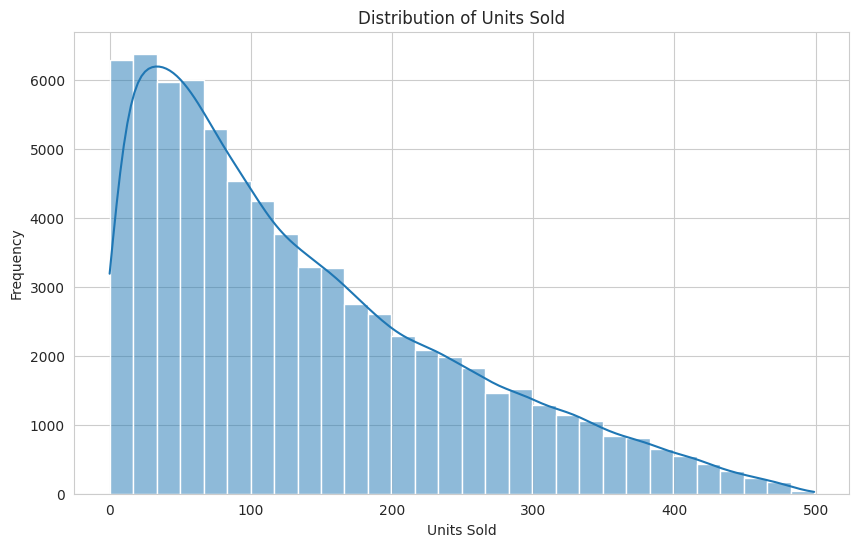

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Distribution of 'Units Sold'
plt.figure(figsize=(10, 6))
sns.histplot(df['Units Sold'], bins=30, kde=True)
plt.title('Distribution of Units Sold')
plt.xlabel('Units Sold')
plt.ylabel('Frequency')
plt.show()

/tmp/ipykernel_1021/1380592942.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Category', data=df, order = df['Category'].value_counts().index, palette='viridis')


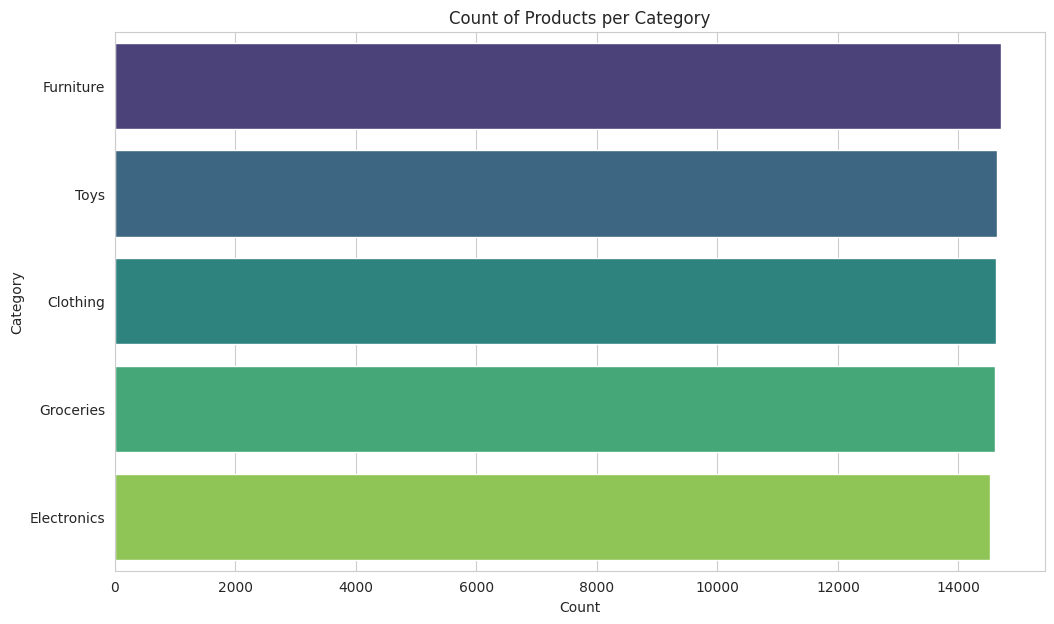

In [7]:
# Count of products per Category
plt.figure(figsize=(12, 7))
sns.countplot(y='Category', data=df, order = df['Category'].value_counts().index, palette='viridis')
plt.title('Count of Products per Category')
plt.xlabel('Count')
plt.ylabel('Category')
plt.show()

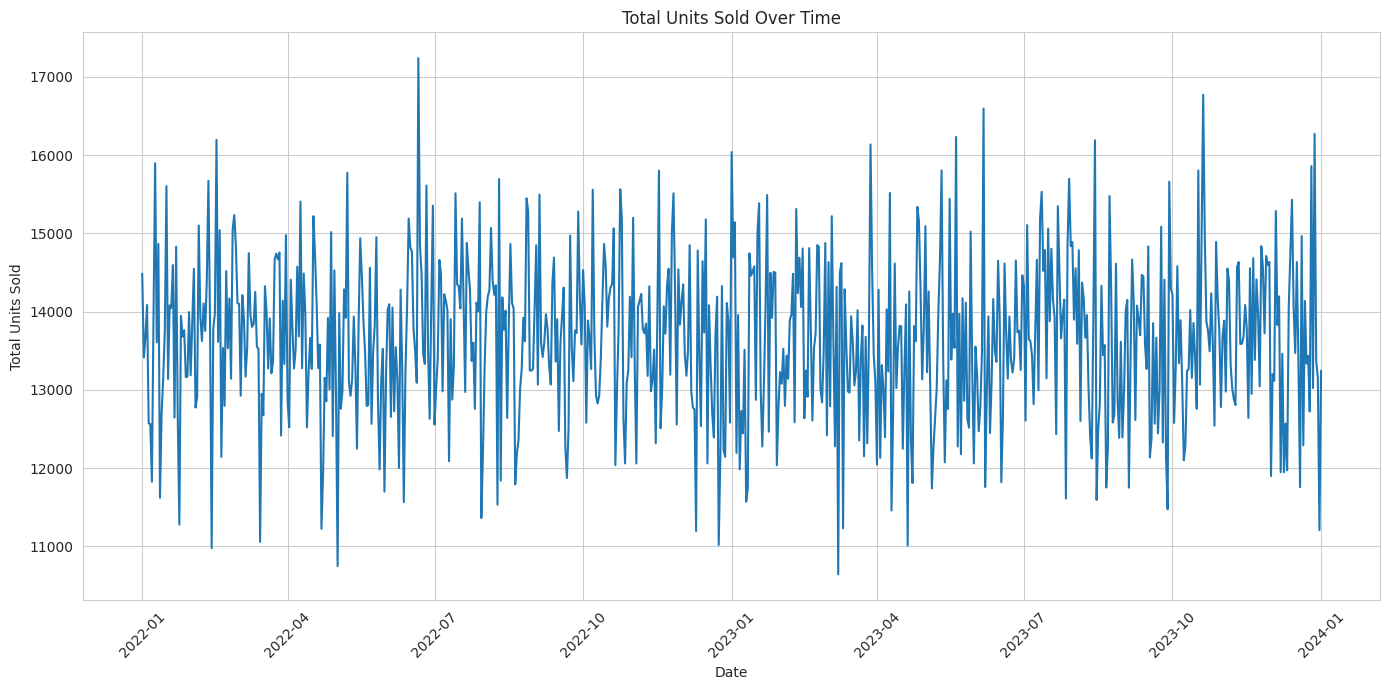

In [8]:
# Time series of 'Units Sold' (daily sum)
# First, aggregate units sold by date
daily_sales = df.groupby('Date')['Units Sold'].sum().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(x='Date', y='Units Sold', data=daily_sales)
plt.title('Total Units Sold Over Time')
plt.xlabel('Date')
plt.ylabel('Total Units Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Machine Learning Models

#### 1. Data Preparation for Modeling

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define features (X) and target (y)
X = df.drop(['Units Sold', 'Date'], axis=1) # Dropping 'Date' for this regression task
y = df['Units Sold']

# Identify categorical and numerical columns
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

# Create a column transformer for one-hot encoding categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data preparation complete. X_train and X_test are ready for preprocessing and modeling.")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")

Data preparation complete. X_train and X_test are ready for preprocessing and modeling.
Shape of X_train: (58480, 13)
Shape of X_test: (14620, 13)


#### 2. Model Training and Evaluation

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Dictionary to store models and their names
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42),
    'Random Forest Regressor': RandomForestRegressor(random_state=42, n_estimators=100),
    'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=42, n_estimators=100),
    'XGBoost Regressor': XGBRegressor(random_state=42, n_estimators=100)
}

results = {}

for name, model in models.items():
    print(f"\n--- Training {name} ---")
    # Create a pipeline with preprocessing and the model
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', model)])

    # Train the model
    pipeline.fit(X_train, y_train)

    # Make predictions
    y_pred = pipeline.predict(X_test)

    # Evaluate the model
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = mse**0.5
    r2 = r2_score(y_test, y_pred)

    results[name] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

    print(f"{name} Results:")
    print(f"  MAE: {mae:.2f}")
    print(f"  MSE: {mse:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  R2 Score: {r2:.2f}")

print("\n--- Model Training and Evaluation Complete ---")
print("\nSummary of all models' performance:")
for name, metrics in results.items():
    print(f"{name}:")
    for metric, value in metrics.items():
        print(f"  {metric}: {value:.2f}")


--- Training Linear Regression ---
Linear Regression Results:
  MAE: 7.42
  MSE: 74.03
  RMSE: 8.60
  R2 Score: 0.99

--- Training Decision Tree Regressor ---
Decision Tree Regressor Results:
  MAE: 9.58
  MSE: 140.56
  RMSE: 11.86
  R2 Score: 0.99

--- Training Random Forest Regressor ---
Random Forest Regressor Results:
  MAE: 7.26
  MSE: 73.26
  RMSE: 8.56
  R2 Score: 0.99

--- Training Gradient Boosting Regressor ---
Gradient Boosting Regressor Results:
  MAE: 7.24
  MSE: 71.62
  RMSE: 8.46
  R2 Score: 0.99

--- Training XGBoost Regressor ---
XGBoost Regressor Results:
  MAE: 7.27
  MSE: 73.44
  RMSE: 8.57
  R2 Score: 0.99

--- Model Training and Evaluation Complete ---

Summary of all models' performance:
Linear Regression:
  MAE: 7.42
  MSE: 74.03
  RMSE: 8.60
  R2: 0.99
Decision Tree Regressor:
  MAE: 9.58
  MSE: 140.56
  RMSE: 11.86
  R2: 0.99
Random Forest Regressor:
  MAE: 7.26
  MSE: 73.26
  RMSE: 8.56
  R2: 0.99
Gradient Boosting Regressor:
  MAE: 7.24
  MSE: 71.62
  RMSE:

### 3. Visualizing Model Predictions

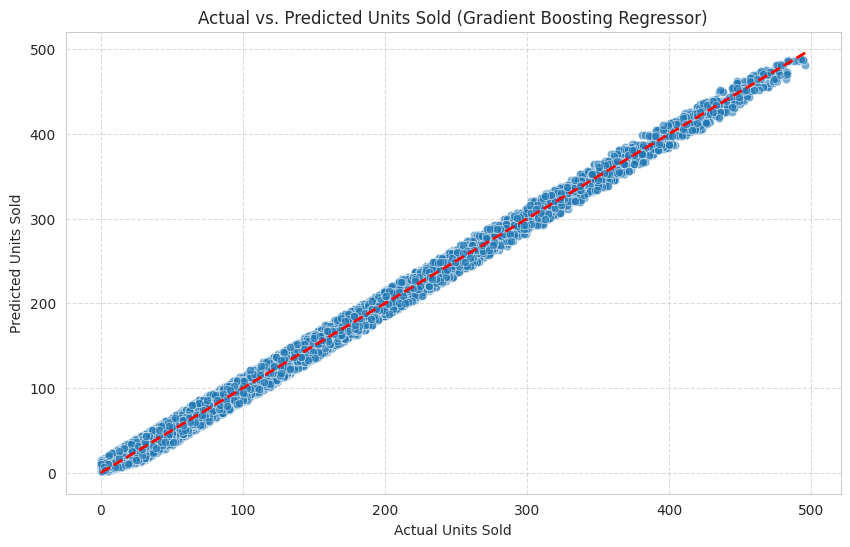

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the best performing model (Gradient Boosting Regressor)
best_model_name = 'Gradient Boosting Regressor'
best_model = models[best_model_name]

# Re-create and train the pipeline for the best model
best_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', best_model)])
best_pipeline.fit(X_train, y_train)

# Make predictions on the test set using the best model
y_pred_best = best_pipeline.predict(X_test)

# Create a DataFrame for plotting
predictions_df = pd.DataFrame({'Actual Units Sold': y_test, 'Predicted Units Sold': y_pred_best})

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Actual Units Sold', y='Predicted Units Sold', data=predictions_df, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f'Actual vs. Predicted Units Sold ({best_model_name})')
plt.xlabel('Actual Units Sold')
plt.ylabel('Predicted Units Sold')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

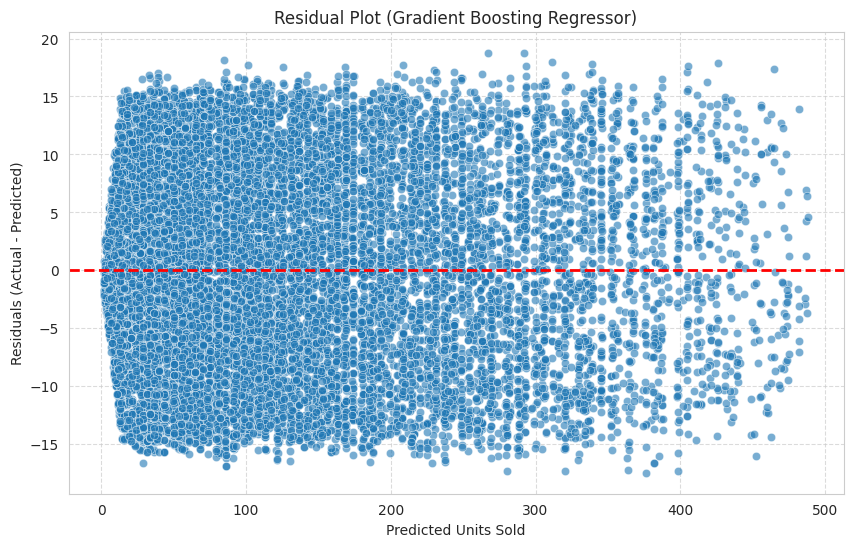

In [12]:
# Residual Plot
residuals = y_test - y_pred_best

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_best, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.title(f'Residual Plot ({best_model_name})')
plt.xlabel('Predicted Units Sold')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### 4. Saving the Trained Model

In [13]:
import pickle

# Save the best performing pipeline
filename = 'model.pkl'
pickle.dump(best_pipeline, open(filename, 'wb'))

print(f"Best model (Gradient Boosting Regressor pipeline) saved as '{filename}'")

Best model (Gradient Boosting Regressor pipeline) saved as 'model.pkl'


### 5. Creating Deployment Files (`app.py` and `requirements.txt`)

In [14]:
%%writefile app.py

import pickle
import pandas as pd
from flask import Flask, request, jsonify

app = Flask(__name__)

# Load the trained model pipeline
try:
    with open('model.pkl', 'rb') as file:
        model_pipeline = pickle.load(file)
    print("Model loaded successfully.")
except Exception as e:
    print(f"Error loading model: {e}")
    model_pipeline = None

@app.route('/predict', methods=['POST'])
def predict():
    if model_pipeline is None:
        return jsonify({'error': 'Model not loaded.'}), 500

    try:
        # Get data from the request
        data = request.get_json(force=True)

        # Convert input data to DataFrame, ensuring correct order and columns
        # It's crucial that the input features match the training features
        input_df = pd.DataFrame([data])

        # Make prediction
        prediction = model_pipeline.predict(input_df)

        # Return the prediction
        return jsonify({'predicted_units_sold': prediction[0]})

    except Exception as e:
        return jsonify({'error': str(e)}), 400

if __name__ == '__main__':
    # For local development: app.run(debug=True)
    # For deployment, listen on all public IPs
    app.run(host='0.0.0.0', port=5000)

Writing app.py


The `app.py` file creates a simple Flask web service:
- It loads the `model.pkl` file containing the trained Gradient Boosting Regressor pipeline.
- It exposes a `/predict` endpoint that accepts JSON data representing the input features.
- It uses the loaded model to predict `Units Sold` and returns the prediction as JSON.

**Note:** When deploying, ensure the input features in your JSON request match the features used during training (excluding 'Date' and 'Units Sold').

In [15]:
%%writefile requirements.txt
pandas
scikit-learn
xgboost
Flask

Writing requirements.txt


The `requirements.txt` file lists all the Python libraries necessary to run the `app.py` service. You would use this file to install dependencies in your deployment environment (e.g., `pip install -r requirements.txt`).

### 6. Downloading Deployment Files

In [23]:
from google.colab import files

# Download app.py
files.download('app.py')

# Download model.pkl
files.download('model.pkl')

# Download requirements.txt
files.download('requirements.txt')

print("Your files are being downloaded.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Your files are being downloaded.
